In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_3.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.2079688510004903, 0.9527048655569782)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.4362404651739533, 0.6139564660691421)

In [10]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [11]:
each_accu=2*p*r/(p+r)
each_accu

airport_inside    0.963580
artstudio         0.926407
auditorium        0.955224
bakery            0.956661
bar               0.969050
                    ...   
tv_studio         0.919708
videostore        0.931818
waitingroom       0.905830
warehouse         0.971429
winecellar        0.988180
Length: 67, dtype: float64

In [12]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[49,
 56,
 50,
 40,
 64,
 20,
 5,
 62,
 35,
 60,
 24,
 22,
 41,
 1,
 32,
 31,
 9,
 17,
 55,
 63,
 38,
 8,
 36,
 29,
 37,
 47,
 42,
 54,
 7,
 21,
 43,
 45,
 2,
 3,
 6]

In [13]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                        if(softmax.max()<split_mode[2]):
                            indexF.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [4,54,2,20]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [4,54,2,20]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [14]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('loss',0.08)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(4816, 7680)

In [15]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(2105, 1019)

In [16]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [17]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [70]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    elif(data_name=='F'):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)

    criterion = nn.CrossEntropyLoss()
    model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
   
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.44480610088410666,train_accu=0.8052176696542894
Epoch=0,valid_loss=0.6213947385740342,valid_accu=0.690460947503201
0
Epoch=1,train_loss=0.3343326457026063,train_accu=0.8777208706786171
Epoch=1,valid_loss=0.6629067409816991,valid_accu=0.6686939820742638
Epoch=2,train_loss=0.22613405794019736,train_accu=0.9234154929577465
Epoch=2,valid_loss=0.6986829607953793,valid_accu=0.6734955185659411
Epoch=3,train_loss=0.1664590019250954,train_accu=0.9422215108834827
Epoch=3,valid_loss=0.7475013215471626,valid_accu=0.7029449423815621
0
Epoch=4,train_loss=0.12948912943065854,train_accu=0.9523047375160051
Epoch=4,valid_loss=0.7200289938727659,valid_accu=0.7224711907810499
0
Epoch=5,train_loss=0.06704504291137034,train_accu=0.9789532650448144
Epoch=5,valid_loss=0.8863981237179491,valid_accu=0.689820742637644
Epoch=6,train_loss=0.0544414060004294,train_accu=0.9834346991037132
Epoch=6,valid_loss=0.897101871640673,valid_accu=0.7090268886043534
Epoch=7,train_loss=0.03425368860664464,tr

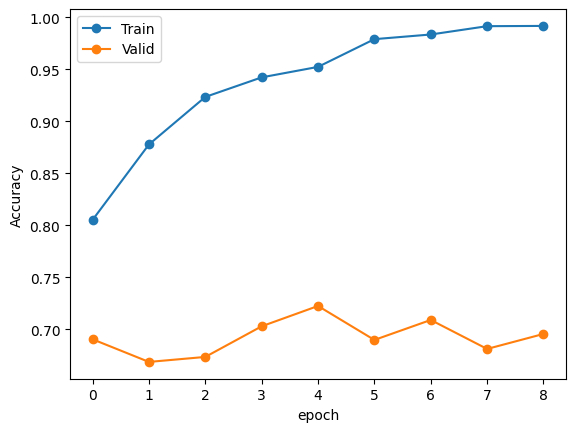

In [53]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

Epoch=0,train_loss=0.08848858723261704,train_accu=0.982421875
Epoch=0,valid_loss=0.08166926960306382,valid_accu=0.9774288518155054
0
Epoch=1,train_loss=0.024583726505322073,train_accu=0.9962239583333333
Epoch=1,valid_loss=0.03477304703460036,valid_accu=0.9931305201177625
0
Epoch=2,train_loss=0.013786432955627485,train_accu=0.99765625
Epoch=2,valid_loss=0.039123536092142364,valid_accu=0.9911678115799804
Epoch=3,train_loss=0.006349223381403135,train_accu=0.9998697916666667
Epoch=3,valid_loss=0.024625113509939043,valid_accu=0.9921491658488715
Epoch=4,train_loss=0.008268902184257361,train_accu=0.998046875
Epoch=4,valid_loss=0.05081850565216843,valid_accu=0.9862610402355251
Epoch=5,train_loss=0.0017131656426802996,train_accu=0.9998697916666667
Epoch=5,valid_loss=0.016015528890434963,valid_accu=0.9950932286555446
0
Epoch=6,train_loss=0.0028657633454713506,train_accu=0.9998697916666667
Epoch=6,valid_loss=0.028720040975405422,valid_accu=0.9882237487733072
Epoch=7,train_loss=0.00203403640537847

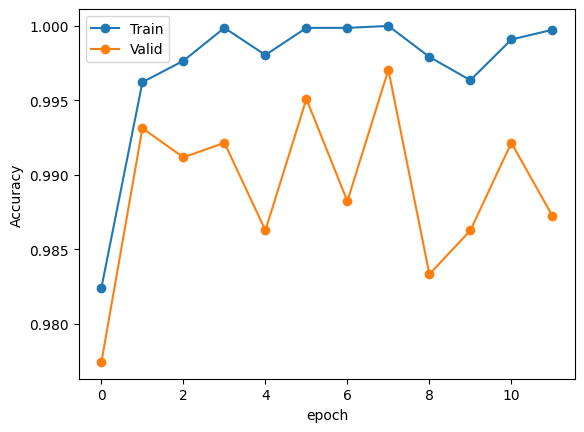

In [22]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.4726334398371042,train_accu=0.6478405315614618
Epoch=0,valid_loss=2.372024225622345,valid_accu=0.3548693586698337
0
Epoch=1,train_loss=0.992603717848312,train_accu=0.772217607973422
Epoch=1,valid_loss=2.095631490920332,valid_accu=0.41092636579572445
0
Epoch=2,train_loss=0.7566641775080531,train_accu=0.8392857142857143
Epoch=2,valid_loss=2.0242262143137335,valid_accu=0.42755344418052255
0
Epoch=3,train_loss=0.61125150788266,train_accu=0.8737541528239202
Epoch=3,valid_loss=1.9885620355039764,valid_accu=0.44085510688836105
0
Epoch=4,train_loss=0.5158551406622726,train_accu=0.9022009966777409
Epoch=4,valid_loss=1.9814262980803174,valid_accu=0.44323040380047507
0
Epoch=5,train_loss=0.4355272257644869,train_accu=0.9240033222591362
Epoch=5,valid_loss=1.9890878765713291,valid_accu=0.44608076009501185
0
Epoch=6,train_loss=0.38396484719162366,train_accu=0.938953488372093
Epoch=6,valid_loss=1.9843135239109575,valid_accu=0.45795724465558196
0
Epoch=7,train_loss=0.3341831756984

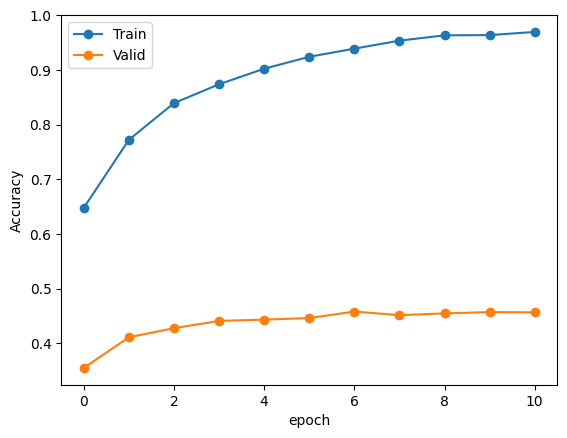

In [61]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [54]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.13012179911670857, 0.951904609475032)

In [55]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.7200289938727659, 0.7224711907810499)

In [26]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.002034036407712847, 1.0)

In [62]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.3839648386271689, 0.938953488372093)

In [28]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.014614530969036412, 0.9970559371933267)

In [63]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.9843135753889831, 0.45795724465558196)

In [64]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.14923115600277306, 0.9764724711907811, 4816)

In [65]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.3418318202645159, 0.6334827144686299, 2105)

In [66]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.1830474007230791, 0.969510243277849, 5416, 7080)

In [67]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.6701713643214462, 0.6235595390524968, 1712, 1412)

In [68]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [71]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split_mode}')
df

split_mode = ('loss', 0.08)


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.207969,0.952705,1.436240,0.613956
1,Model_Decision,0.130122,0.951905,0.130122,0.722471
2,Model_T,0.002034,1.000000,0.014615,0.997056
3,Model_F,0.383965,0.938953,1.984314,0.457957
4,Total_Model,0.183047,0.969510,1.670171,0.623560
5,Total_Model_without_decision,0.149231,0.976472,1.341832,0.633483


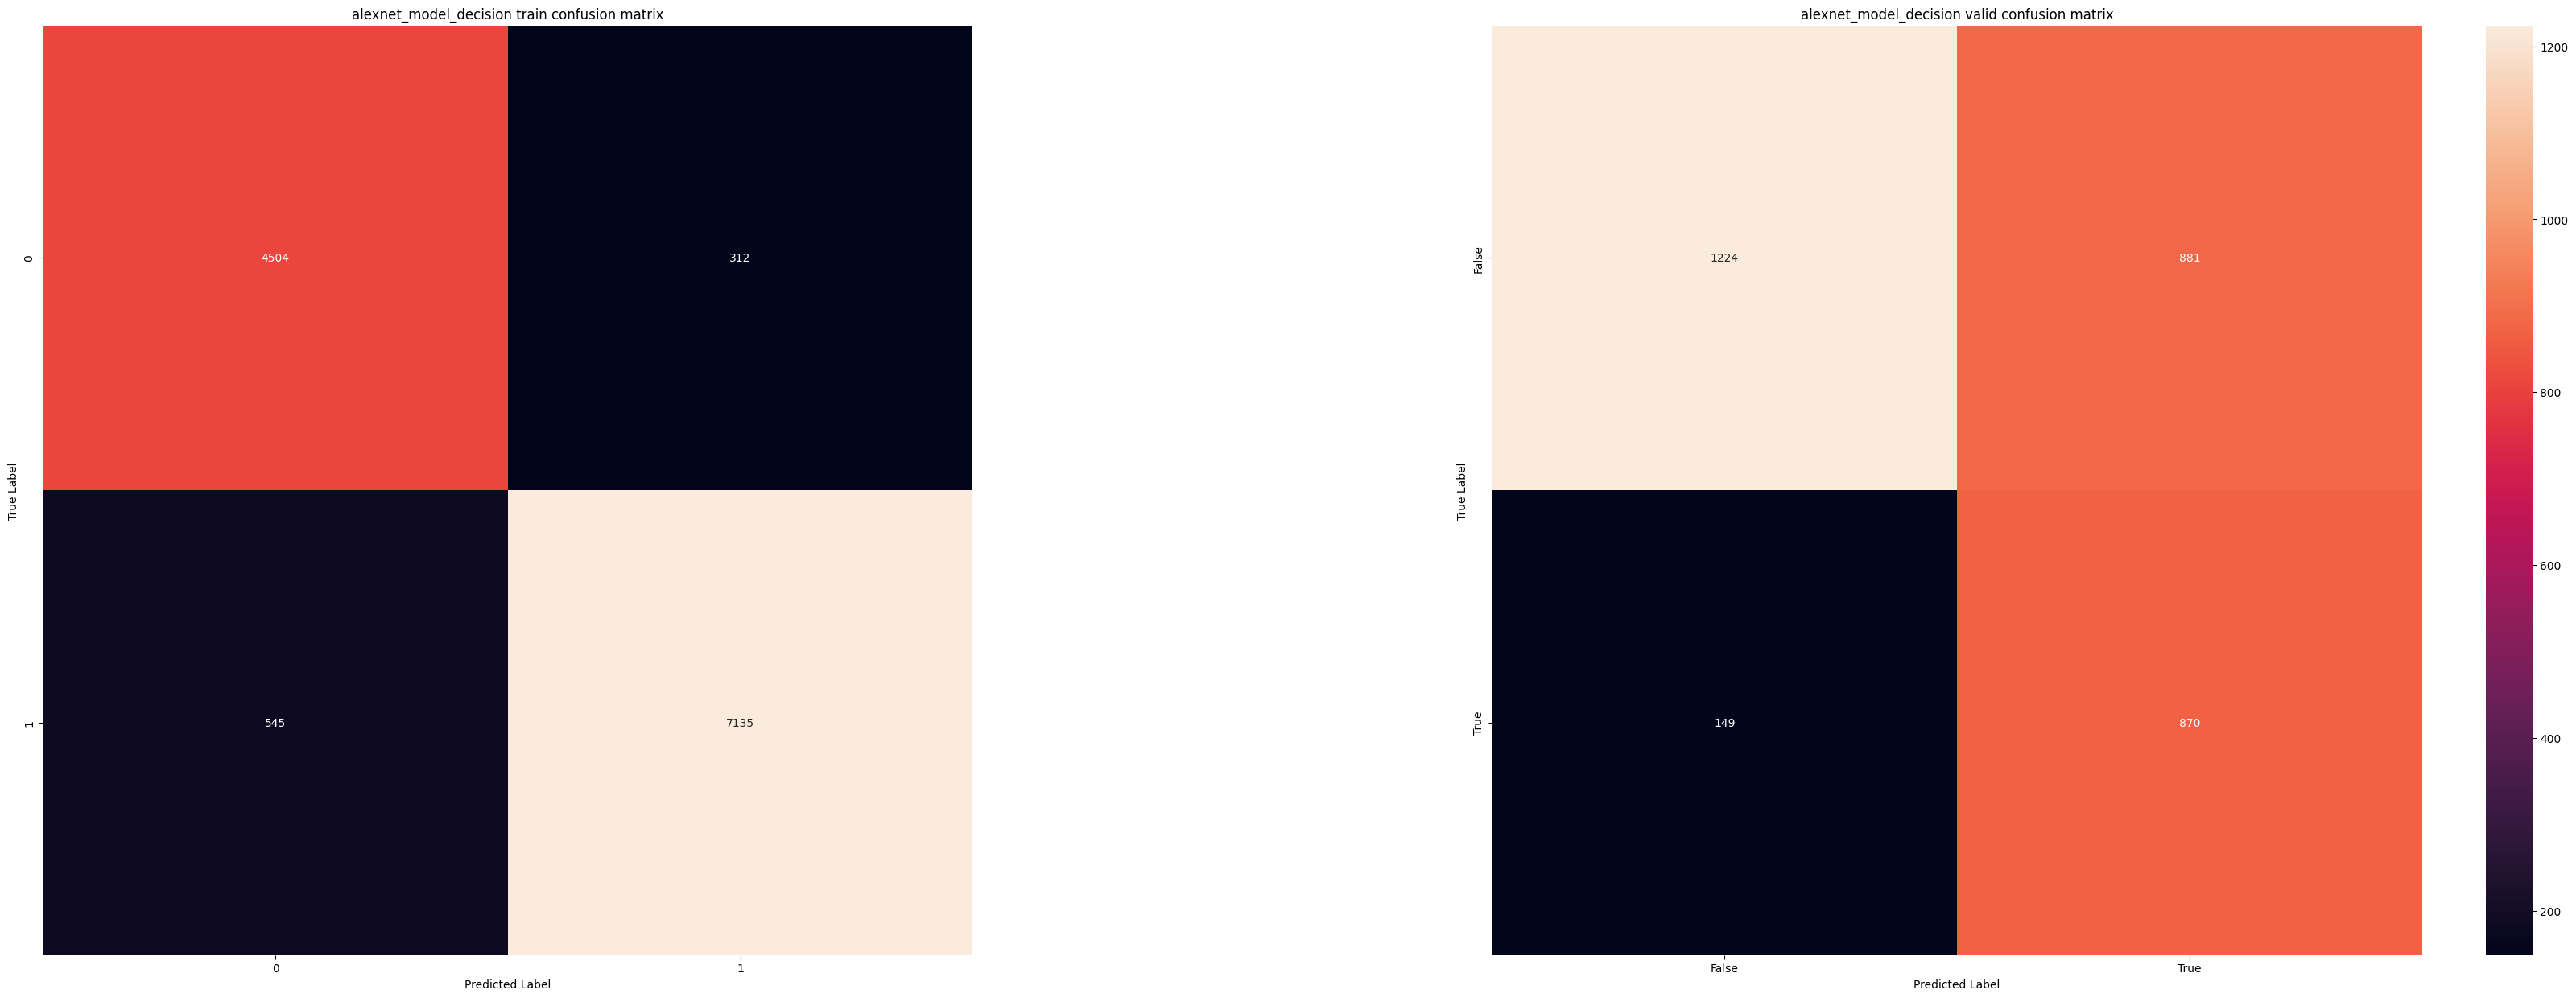

In [36]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

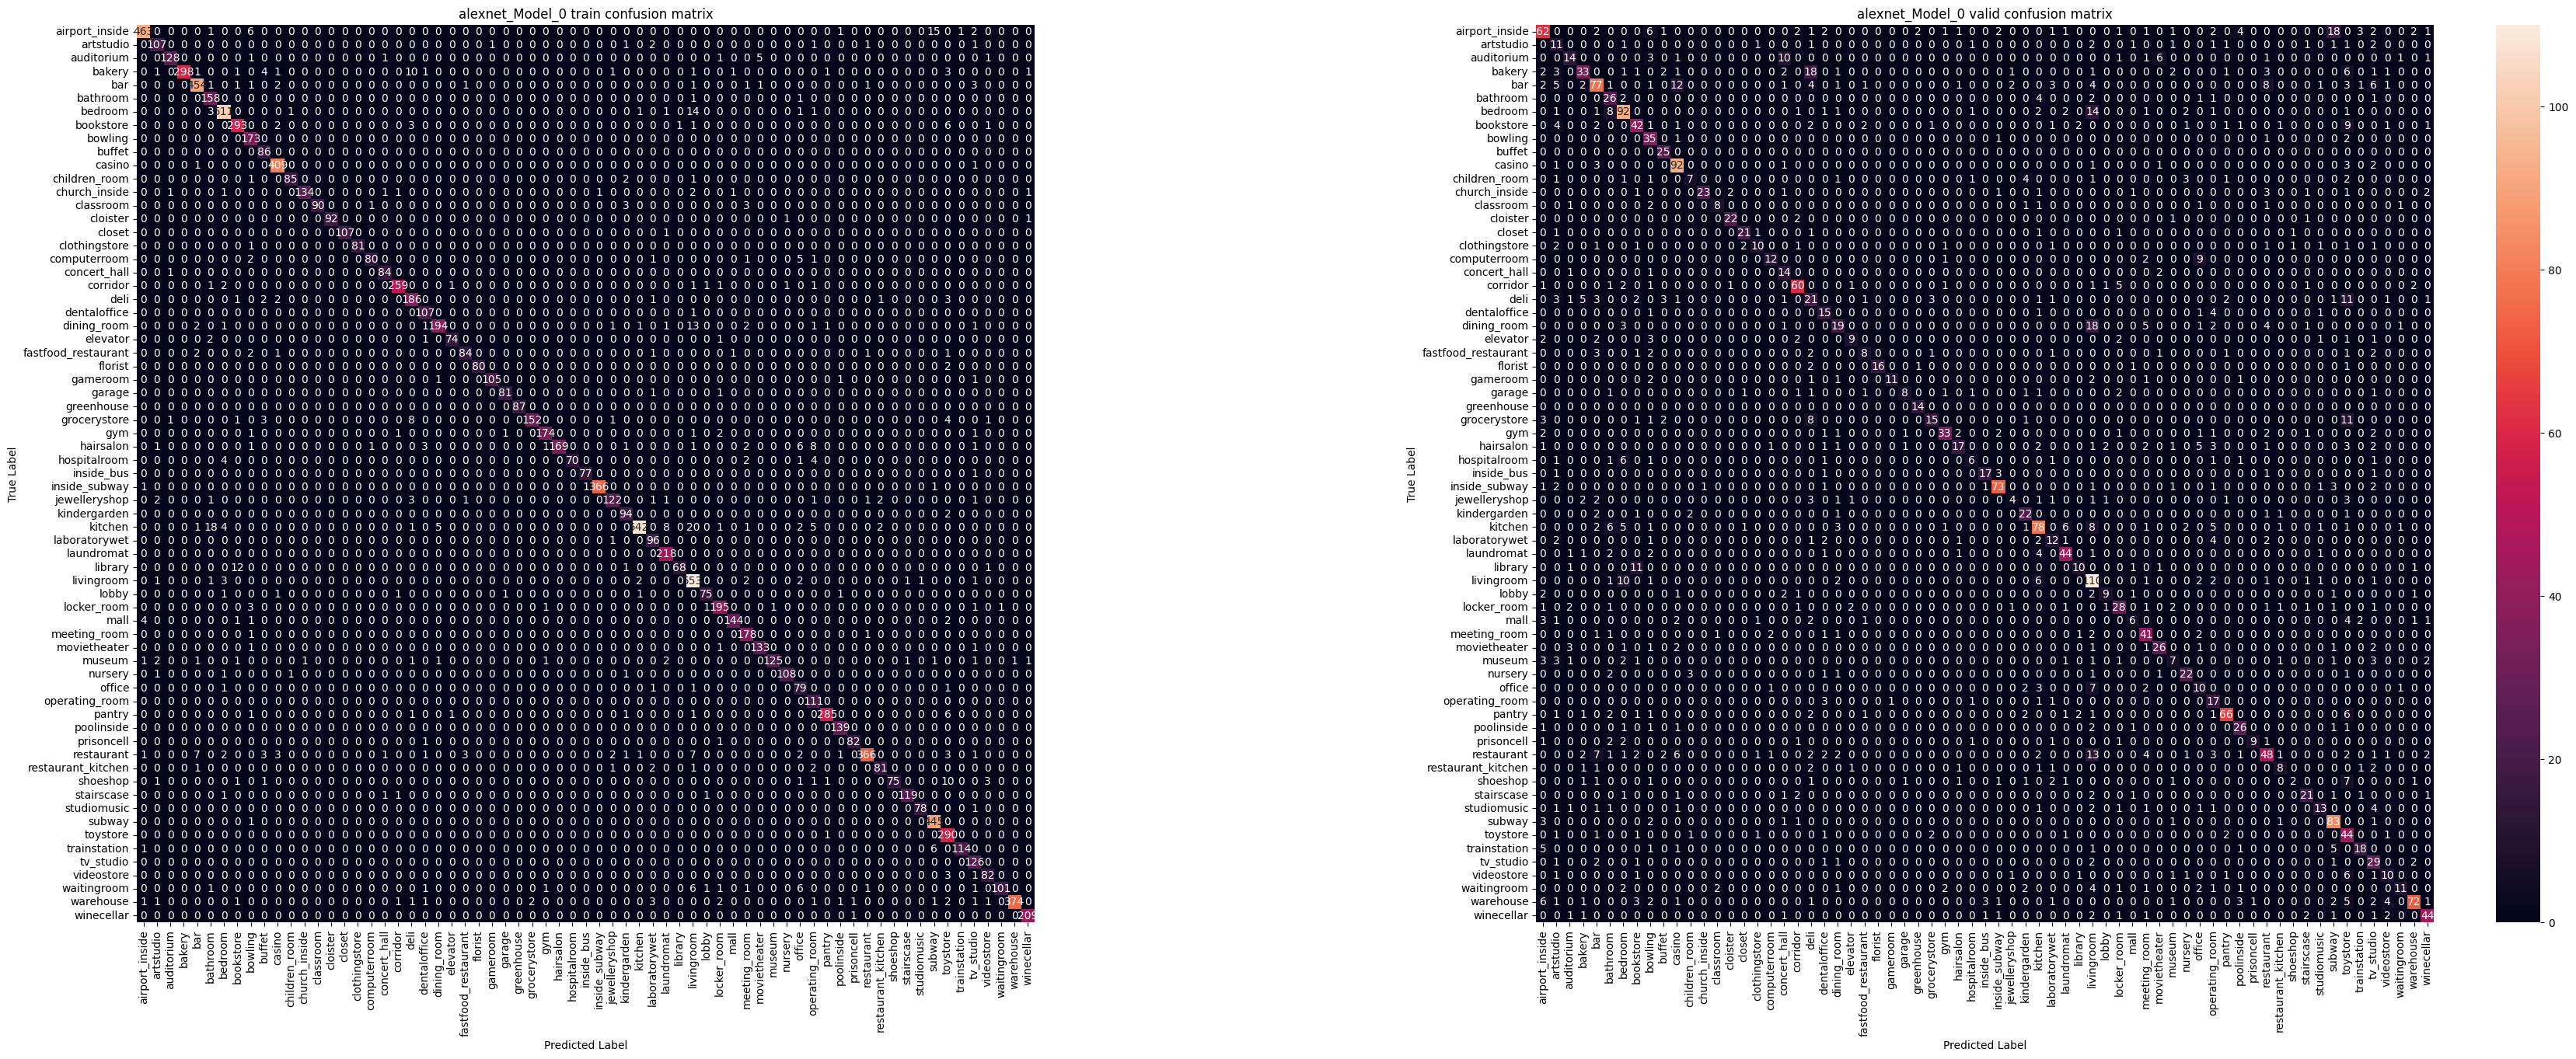

In [37]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

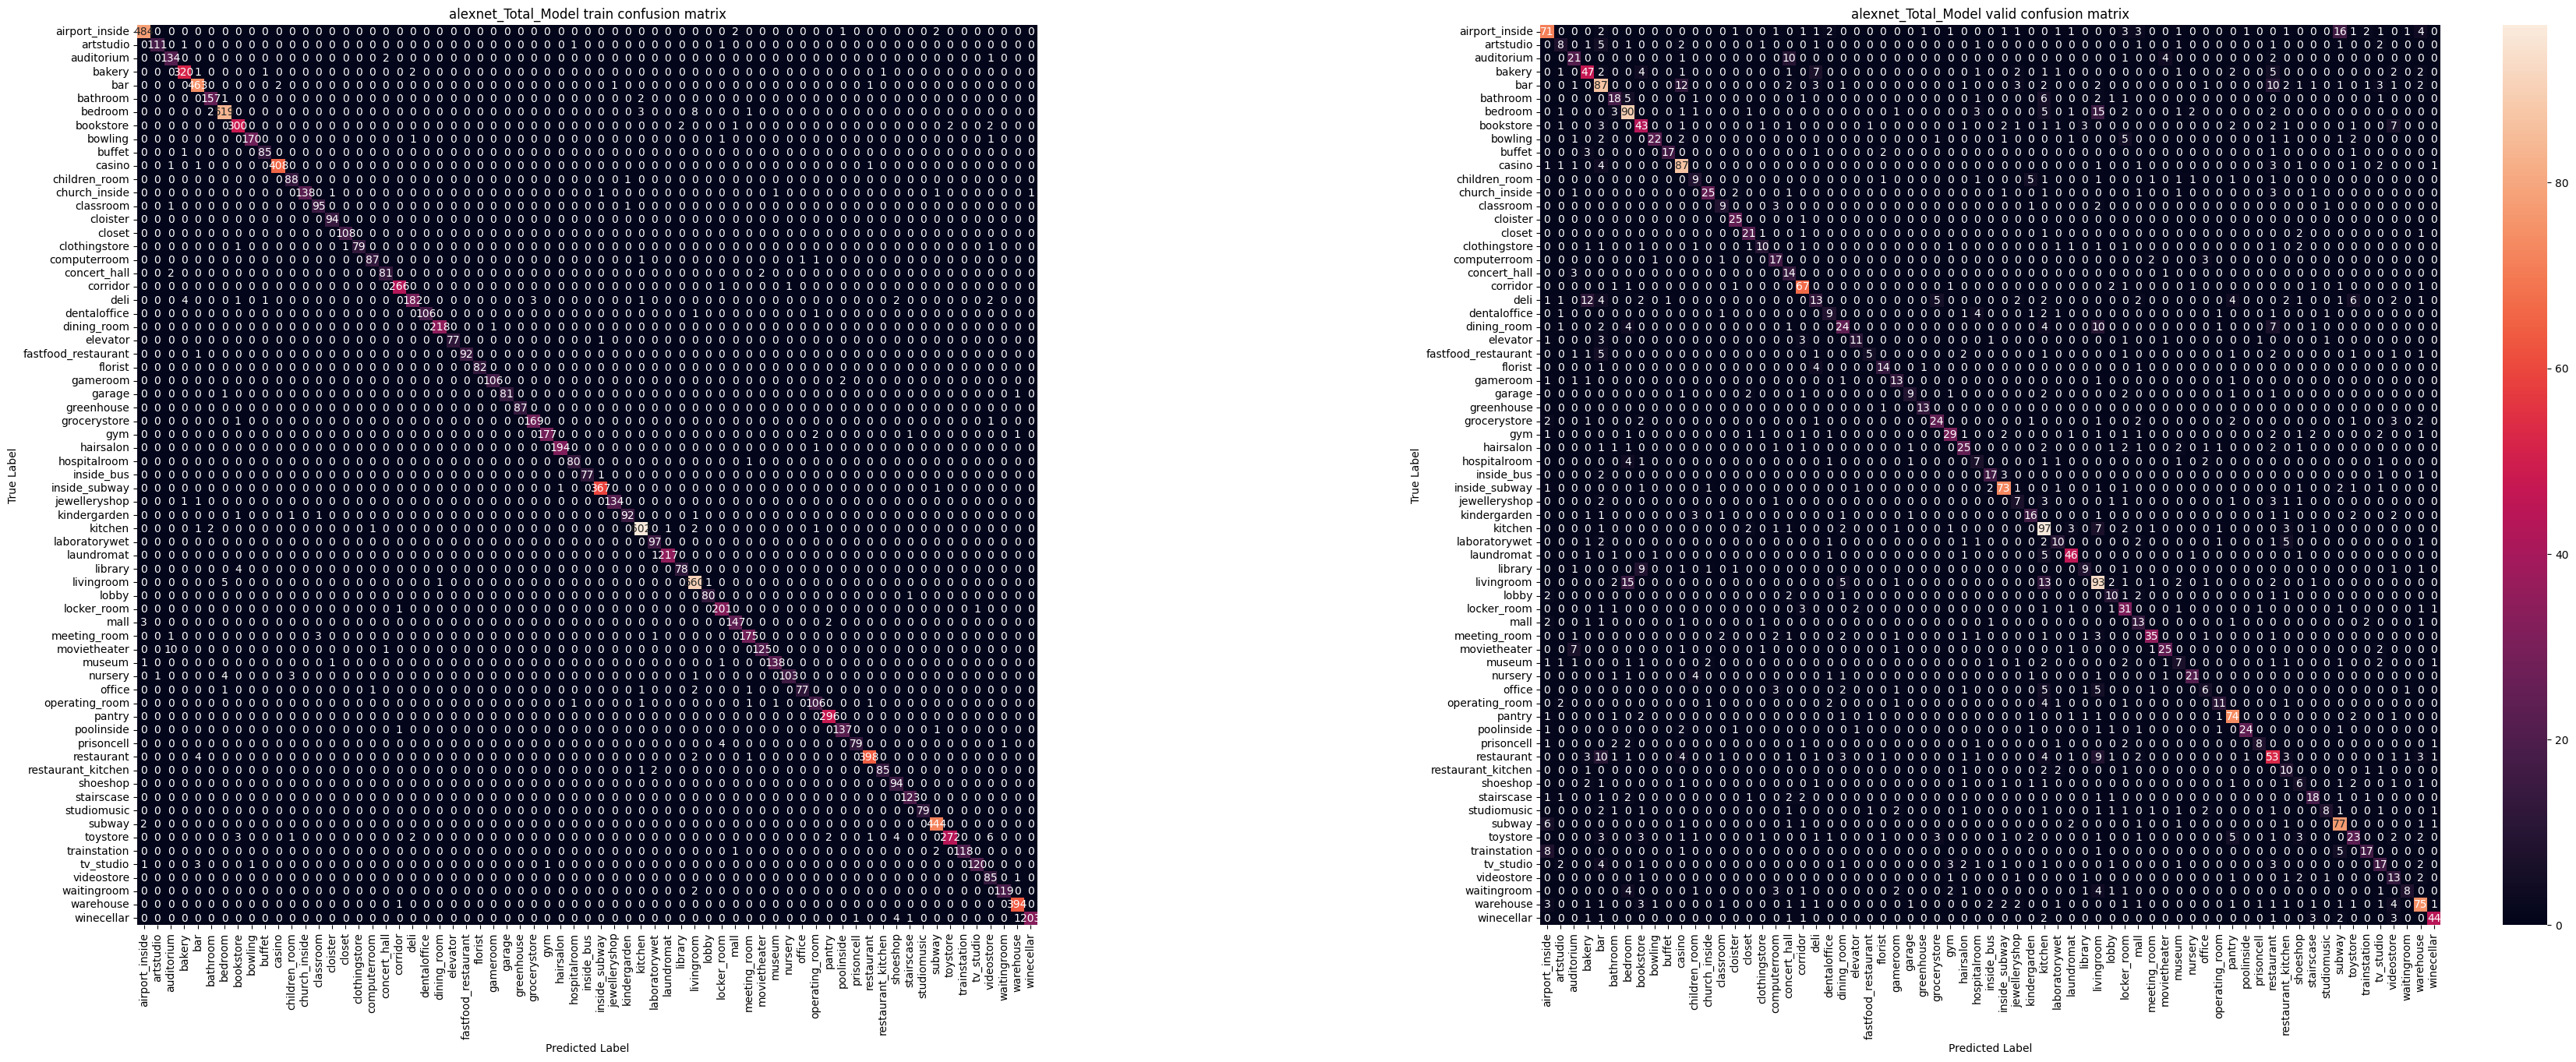

In [38]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

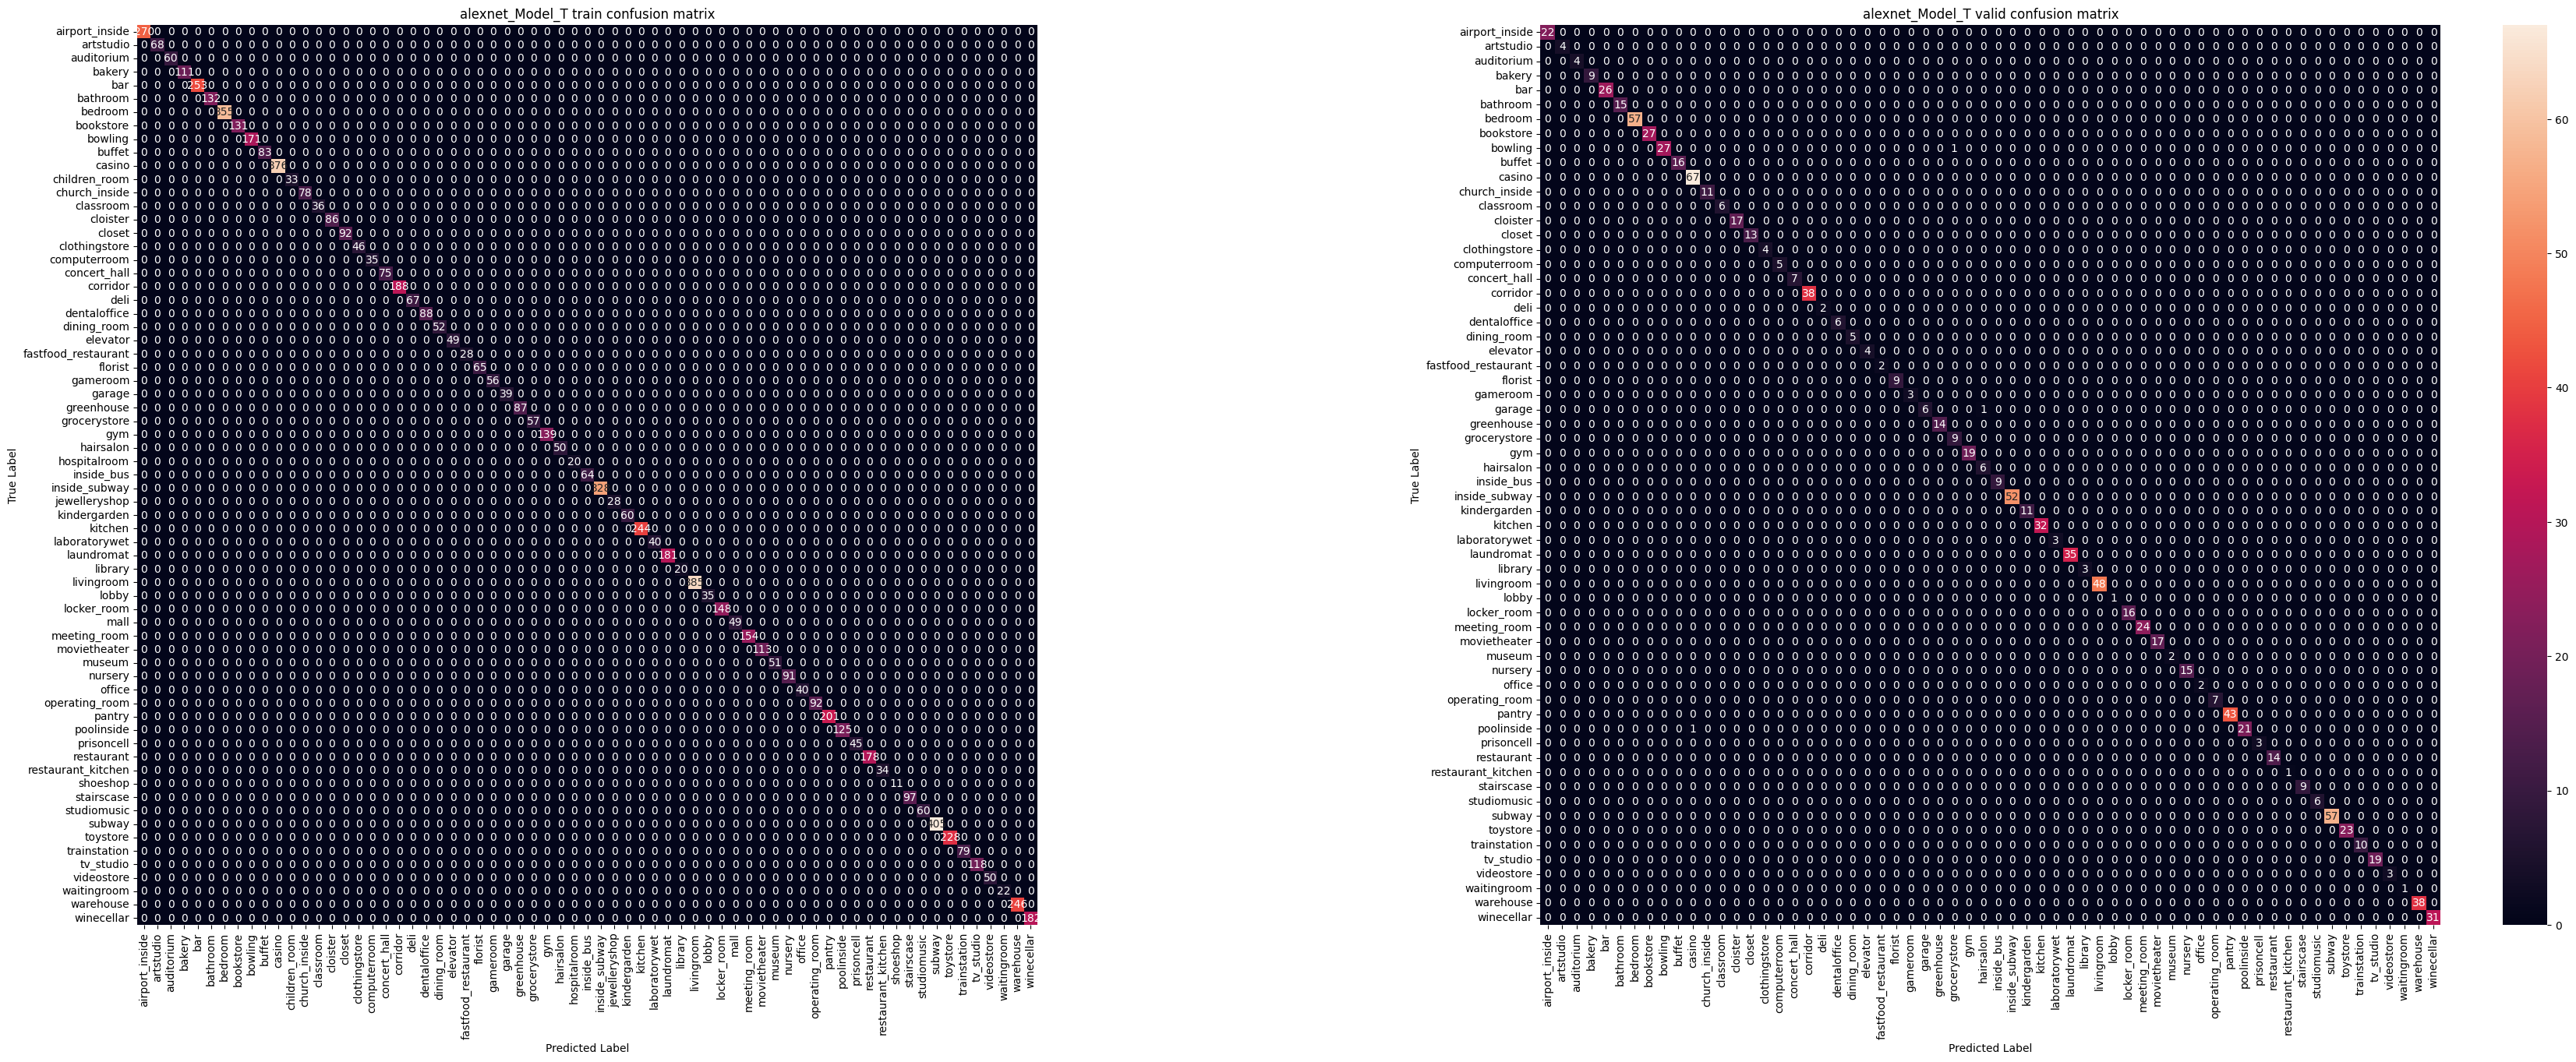

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

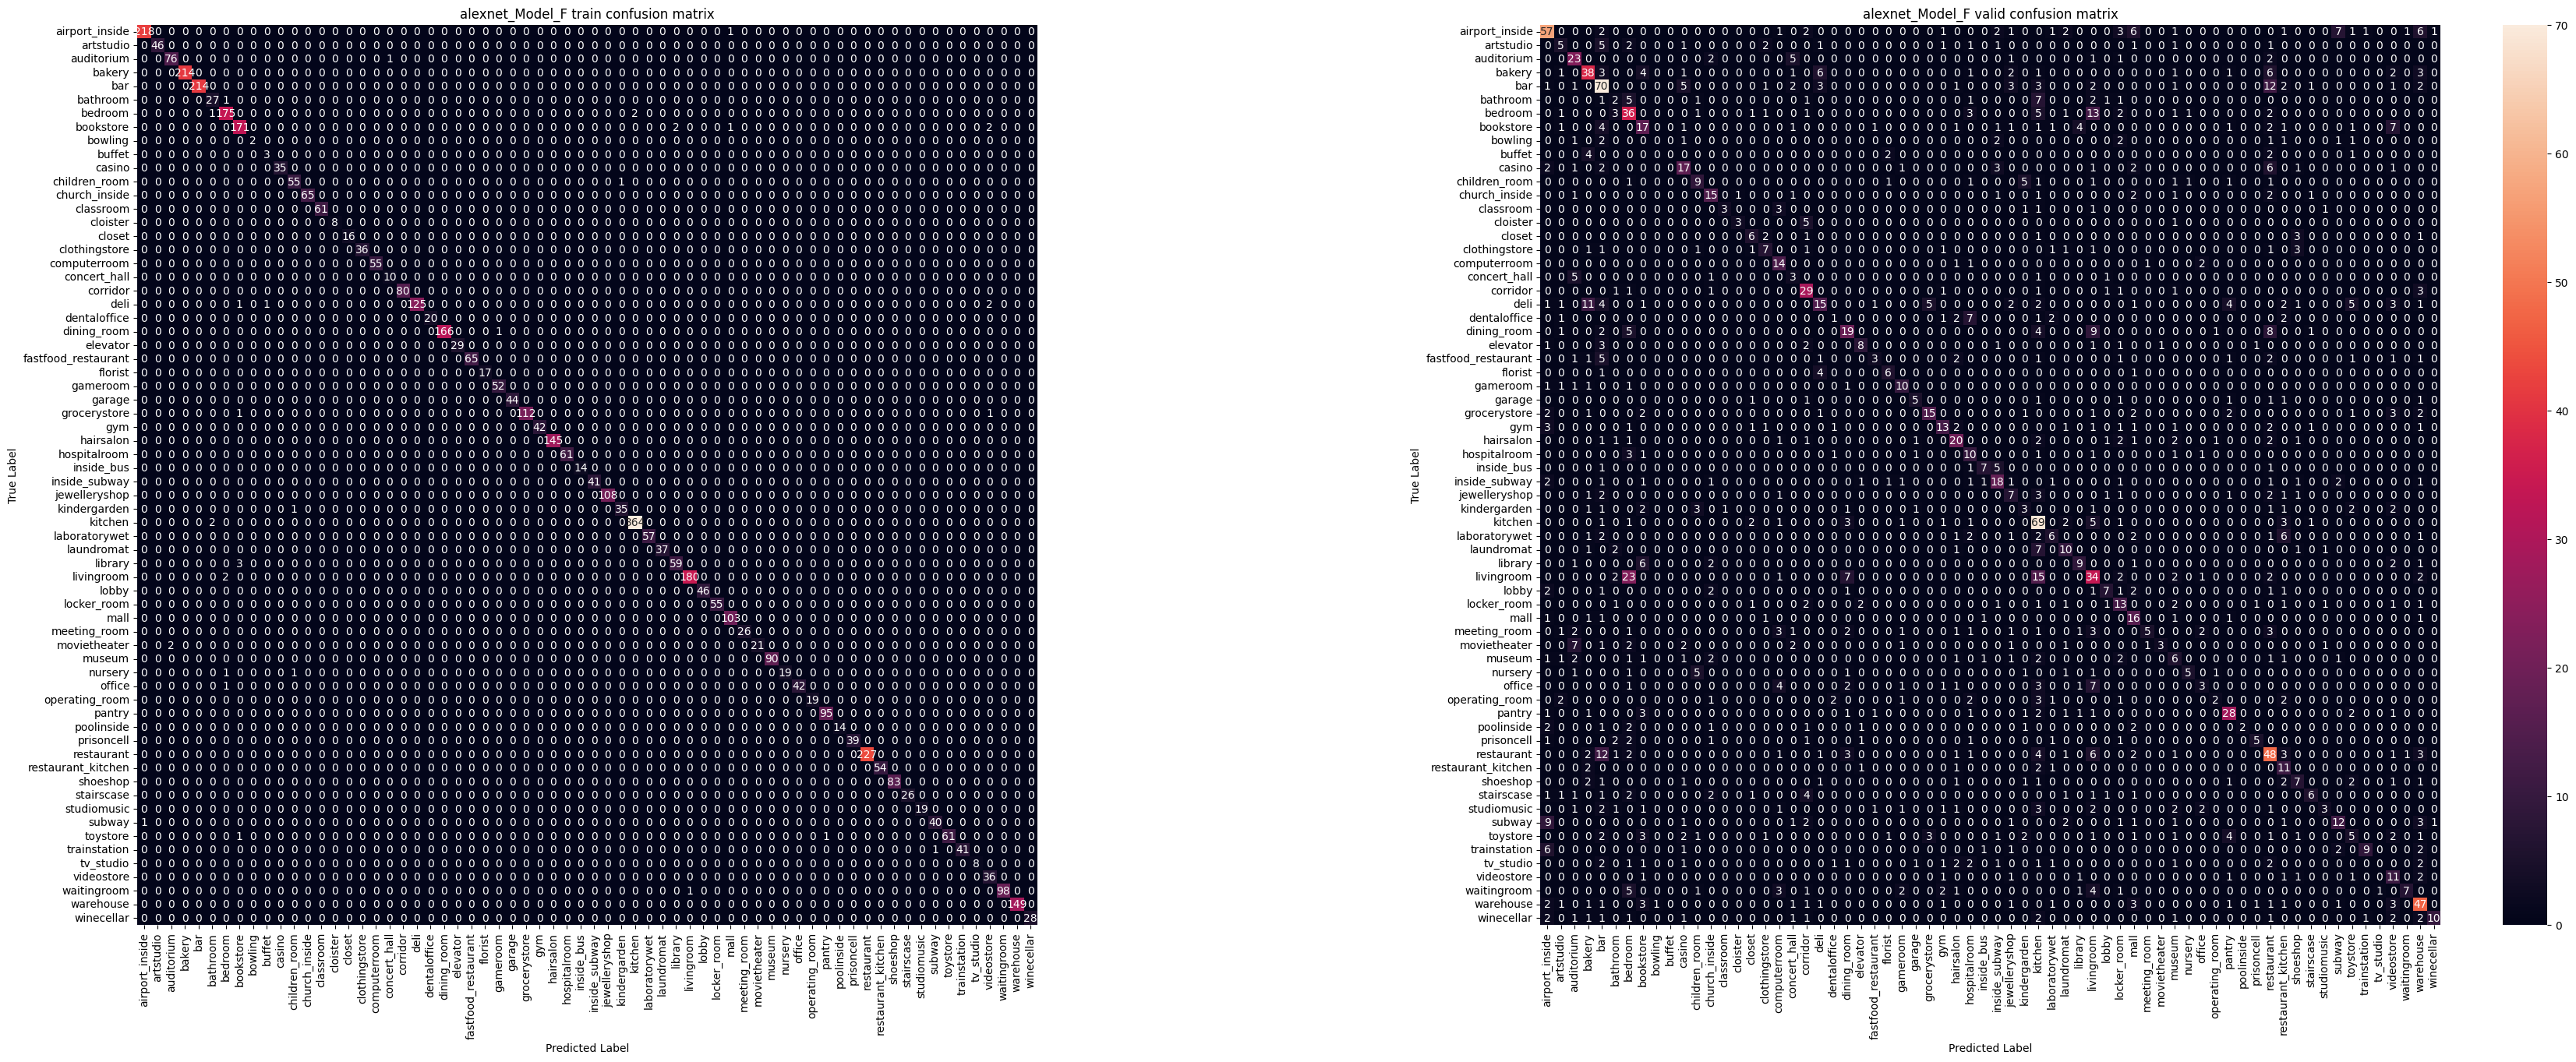

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [41]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [42]:
def calculate_zscore(softmax,avg,max_softmax,min_softmax):
    return (softmax-avg)/(max_softmax-min_softmax)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,6734,29,29,9,9,0.940151,0.955408,0.509663,0.896516,True,False,False,False,False
1,11498,49,49,37,49,0.897490,0.610146,0.817630,0.776540,True,False,True,False,False
2,11132,46,2,46,46,0.999443,1.000000,0.988900,0.939243,False,True,True,True,True
3,7154,31,31,31,31,0.992138,0.999325,0.994389,0.596902,True,True,True,True,True
4,7661,34,34,34,34,0.999773,0.999996,0.998060,0.945176,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,13552,59,0,59,59,0.569143,0.999998,0.999904,0.930479,False,True,True,True,True
12492,183,0,59,0,0,0.457854,0.999884,0.958523,0.873073,False,True,True,True,True
12493,3183,8,17,8,8,0.558361,0.747038,0.999498,0.978093,False,True,True,True,True
12494,14555,62,4,62,62,0.462228,1.000000,0.999721,0.984401,False,True,True,True,True


In [45]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

37    76
60    42
4     39
0     32
6     31
      ..
21     3
8      3
15     2
9      1
14     1
Name: Target, Length: 65, dtype: int64

In [46]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.85)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
35,14623,63,63,63,63,0.993918,0.999919,0.965106,0.814246,True,True,True,False,True
37,1762,4,4,4,4,0.998240,0.993168,0.872930,0.591080,True,True,True,True,False
42,14968,65,65,65,65,0.997180,0.999198,0.954221,0.635232,True,True,True,False,True
45,846,2,2,2,2,0.984253,0.999999,0.986525,0.755959,True,True,True,False,True
52,1911,4,4,4,4,0.993438,0.984345,0.914152,0.558644,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12347,556,0,0,0,0,0.987793,0.999592,0.950001,0.576294,True,True,True,False,True
12414,6117,24,24,24,24,0.498432,0.999032,0.937261,0.529447,True,True,True,False,True
12472,15357,66,66,66,66,0.353332,0.999882,0.984542,0.596479,True,True,True,False,True
12487,2890,7,7,7,7,0.995857,0.558031,0.538387,0.698866,True,True,True,True,False


In [47]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
35,14623,63,63,63,63,0.993918,0.999919,0.965106,0.814246,True,True,True,False,True
37,1762,4,4,4,4,0.998240,0.993168,0.872930,0.591080,True,True,True,True,False
42,14968,65,65,65,65,0.997180,0.999198,0.954221,0.635232,True,True,True,False,True
45,846,2,2,2,2,0.984253,0.999999,0.986525,0.755959,True,True,True,False,True
52,1911,4,4,4,4,0.993438,0.984345,0.914152,0.558644,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12347,556,0,0,0,0,0.987793,0.999592,0.950001,0.576294,True,True,True,False,True
12414,6117,24,24,24,24,0.498432,0.999032,0.937261,0.529447,True,True,True,False,True
12472,15357,66,66,66,66,0.353332,0.999882,0.984542,0.596479,True,True,True,False,True
12487,2890,7,7,7,7,0.995857,0.558031,0.538387,0.698866,True,True,True,True,False


In [48]:
df_results[df_results['Softmax_F'] >df_results['Softmax_T']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,11498,49,49,37,49,0.897490,0.610146,0.817630,0.776540,True,False,True,False,False
14,12984,55,55,55,55,0.997791,0.995680,0.907569,0.708091,True,True,True,False,False
16,2109,5,5,42,5,0.961515,0.955616,0.796459,0.833970,True,False,True,False,False
19,14959,65,65,65,65,0.998822,0.996837,0.910271,0.791687,True,True,True,False,False
21,813,2,2,2,2,0.934014,0.809919,0.899252,0.749012,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12480,12891,54,54,54,54,0.997492,0.559110,0.874105,0.956255,True,True,True,False,False
12481,1299,3,3,3,3,0.958327,0.548894,0.805759,0.920731,True,True,True,False,False
12487,2890,7,7,7,7,0.995857,0.558031,0.538387,0.698866,True,True,True,True,False
12488,6383,26,26,45,26,0.998521,0.736734,0.704329,0.801683,True,False,True,False,False


In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,12074,51,51,51,51,0.989035,1.000000,0.997170,0.987985,True,True,True,True,True
1,11258,47,55,55,55,0.525591,0.767109,0.602420,0.572546,False,False,False,True,False
2,15341,65,65,0,0,0.587218,0.920213,0.840304,0.598116,True,False,False,False,False
3,6991,30,30,30,30,0.607945,0.985395,0.622829,0.533472,True,True,True,True,False
4,243,0,59,59,59,0.905660,0.691958,0.730542,0.855051,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,1482,4,4,4,4,0.978824,0.997318,0.817593,0.517522,True,True,True,False,False
3120,107,0,0,59,59,0.407069,0.958624,0.403375,0.520599,True,False,False,True,False
3121,1716,4,4,62,62,0.898988,0.991298,0.901556,0.622039,True,False,False,False,False
3122,10951,45,45,45,45,0.814951,0.999948,0.998741,0.893368,True,True,True,True,True


In [50]:
df=(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0     60
4     48
41    45
37    42
65    41
      ..
11     4
56     3
24     3
35     2
28     1
Name: Target, Length: 67, dtype: int64

In [51]:
df_results_v[df_results_v['Decision']!=df_results_v['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1,11258,47,55,55,55,0.525591,0.767109,0.602420,0.572546,False,False,False,True,False
3,6991,30,30,30,30,0.607945,0.985395,0.622829,0.533472,True,True,True,True,False
7,454,0,0,0,52,0.977600,0.999390,0.592666,0.765404,True,True,False,True,False
12,8525,37,37,37,37,0.999289,0.999989,0.899331,0.681922,True,True,True,True,False
16,3891,10,0,66,18,0.417796,0.971948,0.295847,0.852066,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,9879,41,37,41,41,0.879954,0.952045,0.435614,0.763652,False,True,True,True,False
3105,7774,34,34,34,59,0.474106,0.788807,0.439424,0.678374,True,True,False,True,False
3111,7446,33,33,34,33,0.858892,0.877554,0.684078,0.820457,True,False,True,True,False
3118,335,0,59,59,59,0.732338,1.000000,0.999261,0.847272,False,False,False,True,False
